# Top Movies Dataset — Exploratory Data Analysis (EDA)
This notebook explores the **Top Movies dataset** (~9.8k movies from TMDB) to understand its structure, clean data-quality issues, and uncover patterns in release dates, popularity, ratings, languages and genres.

**Dataset columns:** `Release_Date`, `Title`, `Overview`, `Popularity`, `Vote_Count`, `Vote_Average`, `Original_Language`, `Genre`, `Poster_Url`, `Working URL`

**Outline:**
1. Setup  
2. Data Loading & First Glance  
3. Data Quality & Cleaning  
4. Type Conversion & Final Check  
5. Univariate Analysis  
6. Bivariate Analysis  
7. Categorical Analysis (Language & Genre)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13

## 1. Setup — Import Libraries
Import `numpy`, `pandas`, `matplotlib` and `seaborn`. Set a consistent visual theme for all plots.

In [2]:
df = pd.read_csv('Top Movies dataset.csv')

## 2. Data Loading & Initial Inspection
Load `Top Movies dataset.csv` and inspect the first rows to understand schema and sample values.

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Working URL
0,15/12/2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,01/03/2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...,https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,25/02/2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,24/11/2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,22/12/2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


### 2.1 Data Structure & Types
`df.info()` shows row count, column null counts and inferred dtypes. Note that `Vote_Count`/`Vote_Average` are strings and `Release_Date` is object — will need conversion later.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
 9   Working URL        9837 non-null   str    
dtypes: float64(1), str(9)
memory usage: 768.6 KB


### 2.2 Missing Values Overview
Count missing values per column to prioritize cleaning. A small cluster (~9–11 rows) is missing across many columns.

In [5]:
df.isna().sum()

Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
Working URL           0
dtype: int64

### 2.3 Inspect Rows with Missing Title
Rows where `Title` is `NaN` appear to be malformed/artifact rows (e.g. `"- Just Desserts"` in `Release_Date`). These should be removed.

In [6]:
df[df['Title'].isna()]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Working URL
1106,- Just Desserts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1107,- If The Hue Fits,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1108,- Dust Up,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1109,- Scents And Sensibility,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1110,- Just One Of The Girls,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1111,- Volleybug,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1112,- Hide And Tink,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1113,- Rainbow's Ends,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1114,- Fawn And Games,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


### 2.4 Cleaning Step 1 — Drop Artifact Rows (Missing Title)
Drop rows where `Title` is missing and reset the index to keep it contiguous.

In [7]:
df.drop(df[df['Title'].isna()].index, inplace=True, index=None)

In [8]:
df.reset_index(drop=True, inplace=True)

### 2.5 Re-check Structure After First Clean
Verify shape drops from 9,837 → ~9,828 and confirm dtypes/nulls after removing title-less rows.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9828 entries, 0 to 9827
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9828 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   str    
 5   Vote_Average       9827 non-null   str    
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
 9   Working URL        9828 non-null   str    
dtypes: float64(1), str(9)
memory usage: 767.9 KB


### 2.6 Inspect Remaining Rows with Any Missing Value
Two remaining problematic rows show shifted columns / parsing errors (e.g. popularity value in Title). These need removal via `dropna`.

In [10]:
df[df.isna().any(axis=1)]

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Working URL
1105,20/10/2013,Pixie Hollow Bake Off,Tink challenges Gelata to see who can bake the...,NaN,NaN,NaN,NaN,NaN,NaN,0
1106,- Magic Tricks,61.328,35,7.1,en,Animation,https://image.tmdb.org/t/p/original/6iXYe7AkQ1...,NaN,NaN,0


### 2.7 Cleaning Step 2 — Drop Residual Incomplete Rows
`dropna()` removes the 2 corrupted rows. Reset index again.

In [11]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

### 2.8 Duplicate Check
Ensure no duplicate rows remain before analysis.

In [12]:
df.duplicated().sum()

np.int64(0)

## 3. Data Type Conversion & Feature Preparation
Convert `Release_Date` → datetime, `Popularity`/`Vote_Count`/`Vote_Average` → numeric, and split `Genre` strings into lists for multi-label analysis.

In [13]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], format="%d/%m/%Y")

In [14]:
df['Popularity'] = pd.to_numeric(df['Popularity'])

In [15]:
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'])

In [16]:
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'])

In [17]:
df['Genre'] = df['Genre'].str.split(', ')

### 3.1 Preview Cleaned DataFrame
Display the cleaned, type-correct DataFrame (≈9,826 rows × 10 cols).

In [18]:
df

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Working URL
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"[Action, Adventure, Science Fiction]",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"[Crime, Mystery, Thriller]",https://image.tmdb.org/t/p/original/74xTEgt7R3...,https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,[Thriller],https://image.tmdb.org/t/p/original/vDHsLnOWKl...,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"[Animation, Comedy, Family, Fantasy]",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"[Action, Adventure, Thriller, War]",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...,...
9821,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"[Drama, Crime]",https://image.tmdb.org/t/p/original/z81rBzHNgi...,https://image.tmdb.org/t/p/original/z81rBzHNgi...
9822,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,[Horror],https://image.tmdb.org/t/p/original/4b6HY7rud6...,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9823,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"[Mystery, Thriller, Horror]",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9824,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"[Music, Drama, History]",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


### 3.2 Final Verification
`info()` and `describe().T` provide a post-cleaning summary: date range 1902–2024, popularity heavily right-skewed, ratings centered ~6.4/10.

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9826 entries, 0 to 9825
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9826 non-null   datetime64[us]
 1   Title              9826 non-null   str           
 2   Overview           9826 non-null   str           
 3   Popularity         9826 non-null   float64       
 4   Vote_Count         9826 non-null   int64         
 5   Vote_Average       9826 non-null   float64       
 6   Original_Language  9826 non-null   str           
 7   Genre              9826 non-null   object        
 8   Poster_Url         9826 non-null   str           
 9   Working URL        9826 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(1), object(1), str(5)
memory usage: 767.8+ KB


In [20]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Release_Date,9826,2006-09-23 04:47:14.276409,1902-04-17 00:00:00,2000-10-17 12:00:00,2011-09-12 00:00:00,2017-11-22 00:00:00,2024-07-03 00:00:00,NaN
Popularity,9826.0,40.324053,13.354,16.12825,21.195,35.17925,5083.954,108.880698
Vote_Count,9826.0,1392.943721,0.0,146.0,444.0,1376.0,31077.0,2611.303856
Vote_Average,9826.0,6.439467,0.0,5.9,6.5,7.1,10.0,1.129797


---
## 4. Univariate Analysis

### 4.1 Release Date — Full Timeline
Histogram + KDE of `Release_Date`. Expect strong recency bias (most movies from 2000+).

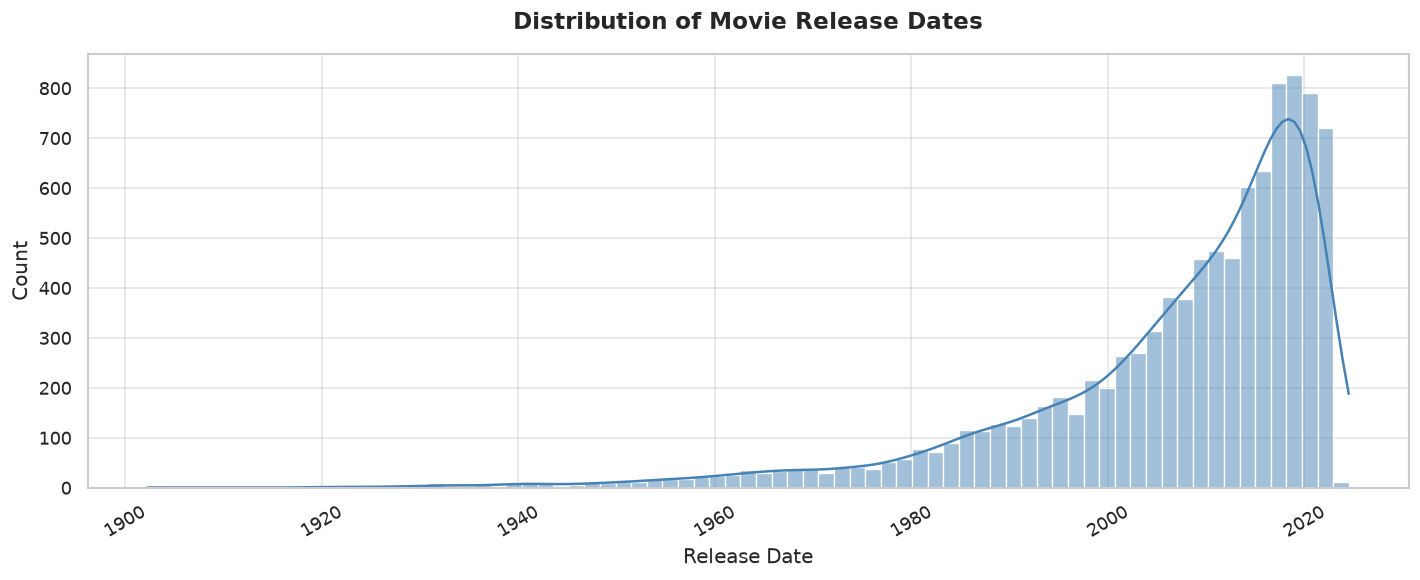

In [21]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Release_Date', kde=True, color='steelblue')
plt.title('Distribution of Movie Release Dates', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Release Date')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 4.1.1 Box Plot of Release Dates
Box plot highlights median (~2011) and outliers (very early 1902 films).

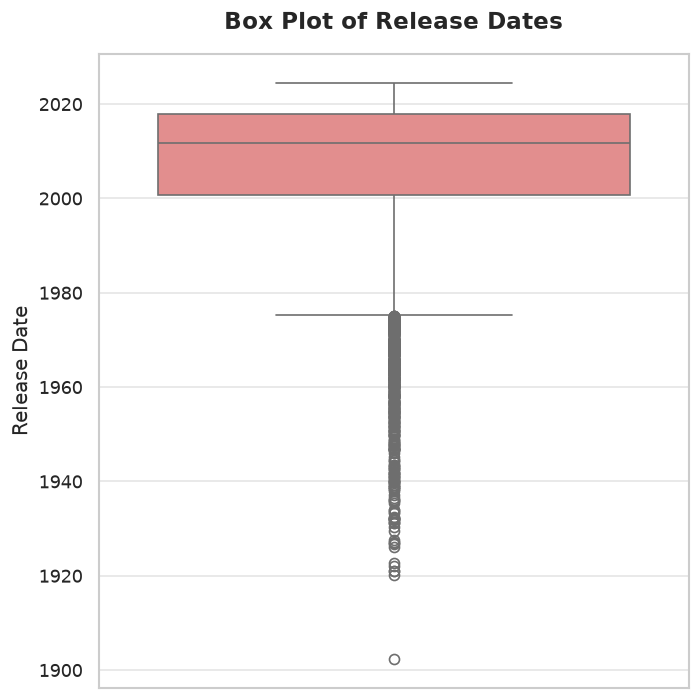

In [22]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df, y='Release_Date', color='lightcoral')
plt.title('Box Plot of Release Dates', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Release Date')
plt.tight_layout()
plt.show()

### 4.1.2 Release Year Distribution
Year-level histogram for cleaner granularity than daily dates.

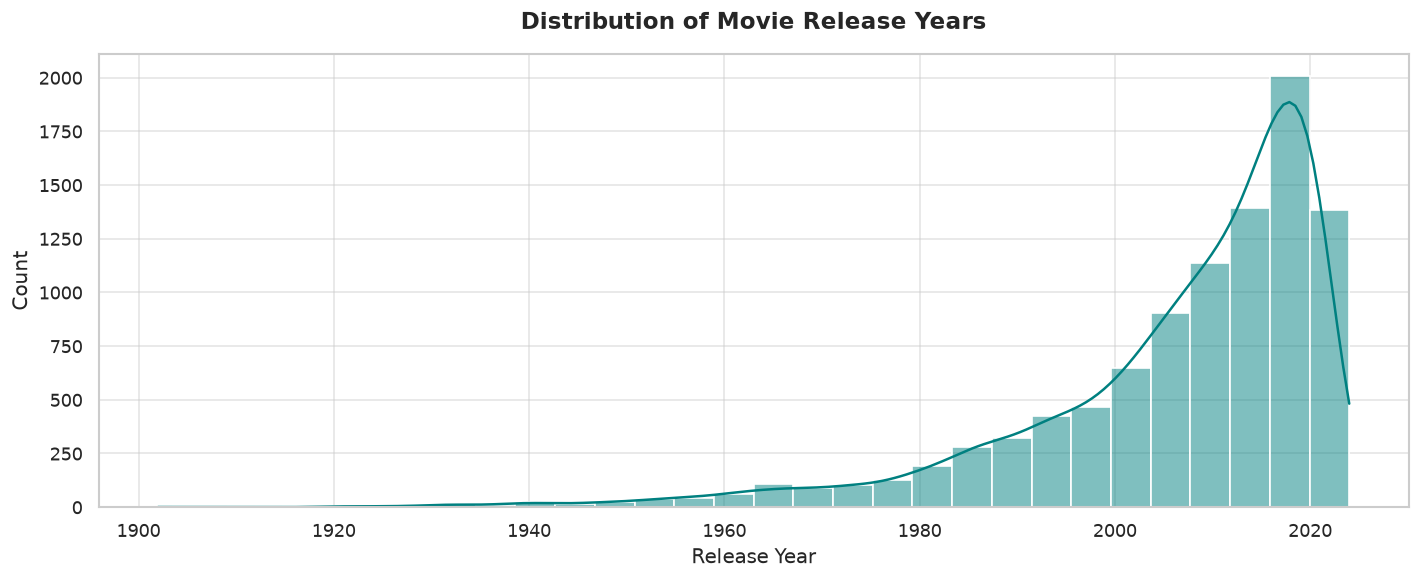

In [23]:
plt.figure(figsize=(12, 5))
sns.histplot(df['Release_Date'].dt.year, kde=True, bins=30, color='teal')
plt.title('Distribution of Movie Release Years', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4.2 Popularity
Overall histogram (50 bins). Distribution is extremely right-skewed — few blockbusters dominate.

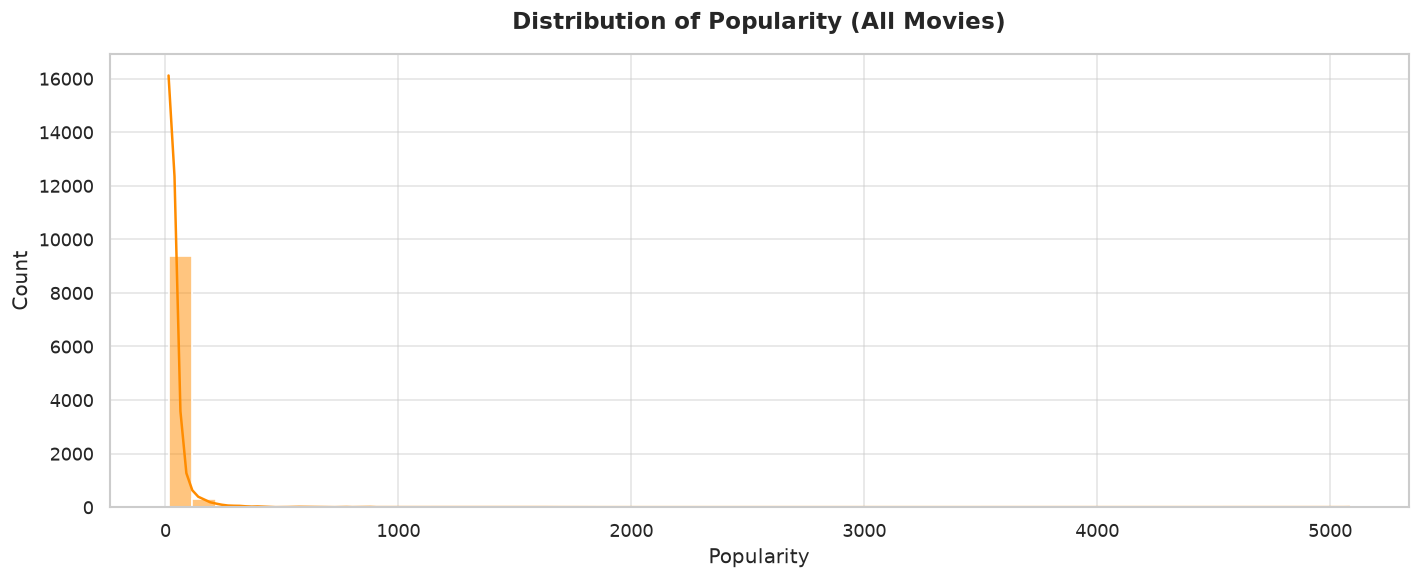

In [24]:
plt.figure(figsize=(12, 5))
sns.histplot(df, x='Popularity', kde=True, bins=50, color='darkorange')
plt.title('Distribution of Popularity (All Movies)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Box Plot of Popularity
Outliers above ~500 are visible. Next cells zoom into the bulk of the distribution.

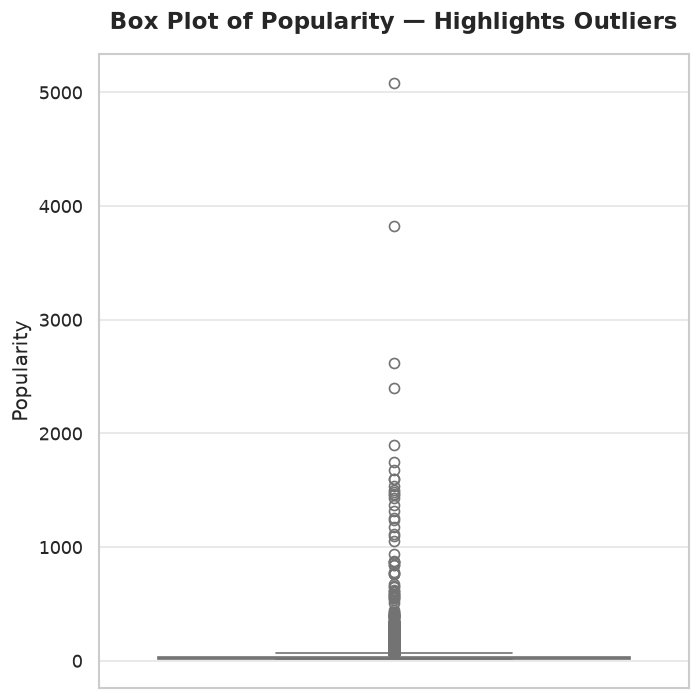

In [25]:
plt.figure(figsize=(6, 6))
sns.boxplot(data=df, y='Popularity', color='lightgreen')
plt.title('Box Plot of Popularity — Highlights Outliers', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()

#### Top Popular Movies
Sorting by `Popularity` confirms outliers: *Spider-Man: No Way Home*, *The Batman*, *Encanto* top the list.

In [26]:
df.sort_values(by = ['Popularity'], ascending = False)

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url,Working URL
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"[Action, Adventure, Science Fiction]",https://image.tmdb.org/t/p/original/1g0dhYtq4i...,https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"[Crime, Mystery, Thriller]",https://image.tmdb.org/t/p/original/74xTEgt7R3...,https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,[Thriller],https://image.tmdb.org/t/p/original/vDHsLnOWKl...,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"[Animation, Comedy, Family, Fantasy]",https://image.tmdb.org/t/p/original/4j0PNHkMr5...,https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"[Action, Adventure, Thriller, War]",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...,https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
...,...,...,...,...,...,...,...,...,...,...
9821,1973-10-15,Badlands,A dramatization of the Starkweather-Fugate kil...,13.357,896,7.6,en,"[Drama, Crime]",https://image.tmdb.org/t/p/original/z81rBzHNgi...,https://image.tmdb.org/t/p/original/z81rBzHNgi...
9822,2020-10-01,Violent Delights,A female vampire falls in love with a man she ...,13.356,8,3.5,es,[Horror],https://image.tmdb.org/t/p/original/4b6HY7rud6...,https://image.tmdb.org/t/p/original/4b6HY7rud6...
9823,2016-05-06,The Offering,When young and successful reporter Jamie finds...,13.355,94,5.0,en,"[Mystery, Thriller, Horror]",https://image.tmdb.org/t/p/original/h4uMM1wOhz...,https://image.tmdb.org/t/p/original/h4uMM1wOhz...
9824,2021-03-31,The United States vs. Billie Holiday,Billie Holiday spent much of her career being ...,13.354,152,6.7,en,"[Music, Drama, History]",https://image.tmdb.org/t/p/original/vEzkxuE2sJ...,https://image.tmdb.org/t/p/original/vEzkxuE2sJ...


#### Zoom: Popularity < 500 & < 100
Two filtered histograms reveal the core distribution once mega-outliers are excluded — still right-skewed but more interpretable.

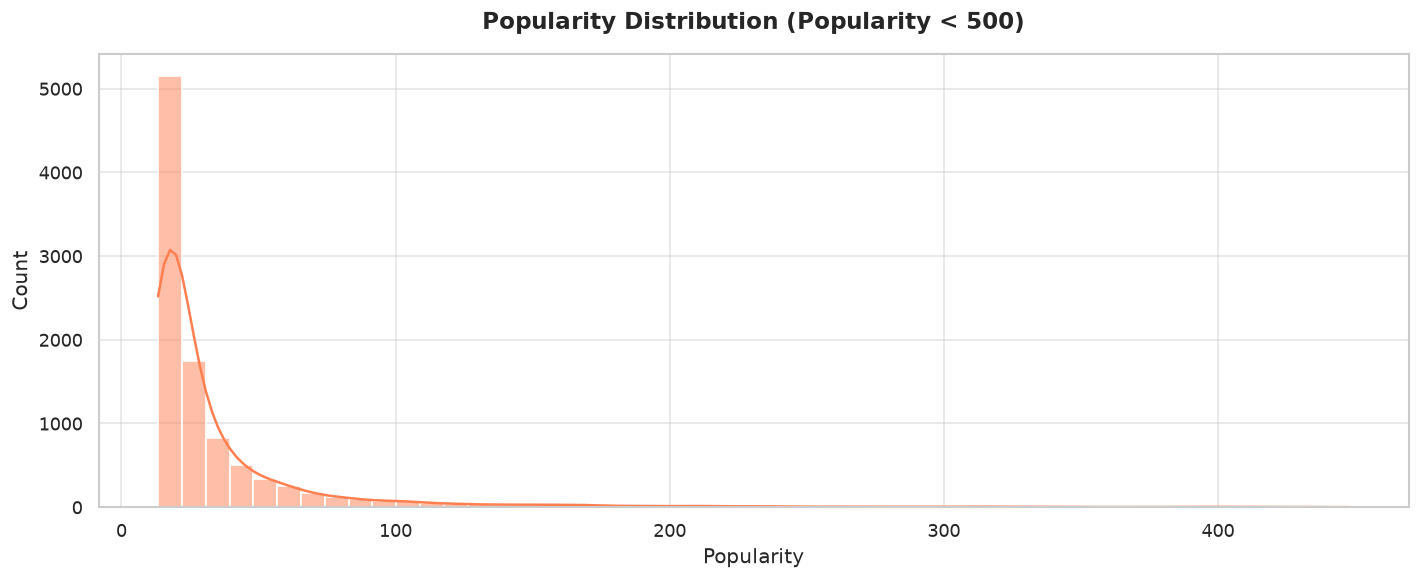

In [27]:
plt.figure(figsize=(12, 5))
sns.histplot(df[df['Popularity'] < 500], x='Popularity', kde=True, bins=50, color='coral')
plt.title('Popularity Distribution (Popularity < 500)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

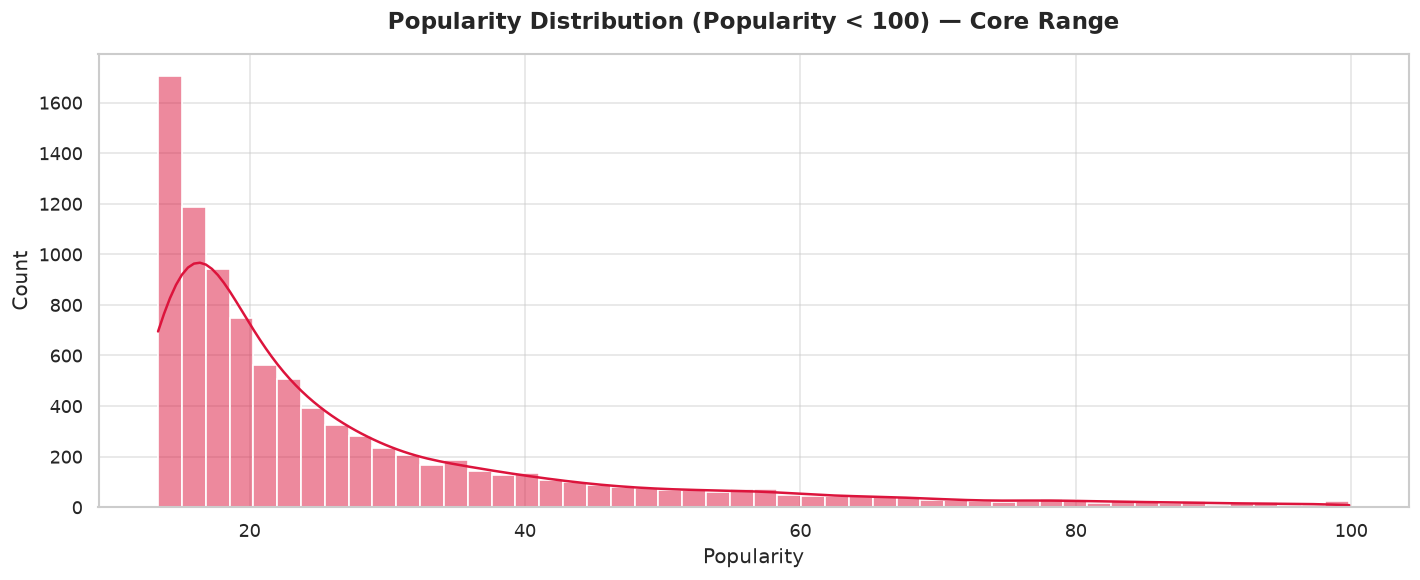

In [28]:
plt.figure(figsize=(12, 5))
sns.histplot(df[df['Popularity'] < 100], x='Popularity', kde=True, bins=50, color='crimson')
plt.title('Popularity Distribution (Popularity < 100) — Core Range', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Popularity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4.3 Vote Count
Vote count is also right-skewed — few movies receive thousands of votes, most receive <1,000.

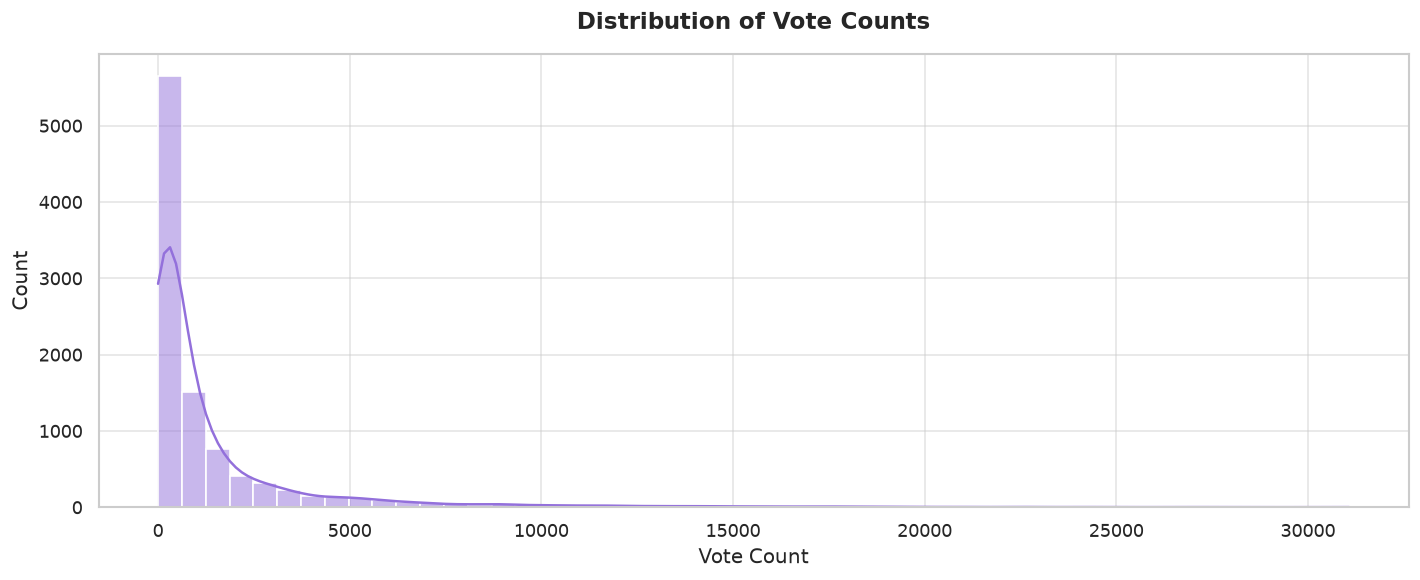

In [29]:
plt.figure(figsize=(12, 5))
sns.histplot(df, x='Vote_Count', kde=True, bins=50, color='mediumpurple')
plt.title('Distribution of Vote Counts', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vote Count')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4.4 Bivariate: Popularity vs Vote Count
Scatter plots (full and zoomed to Popularity 0–1000) plus a regression plot test the intuition that more popular movies get more votes.

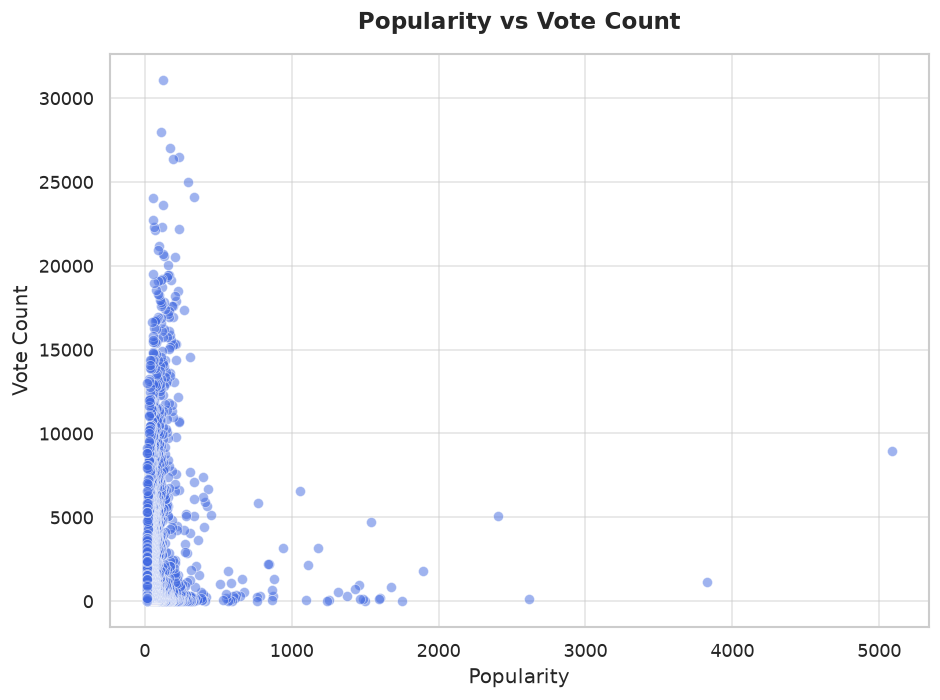

In [30]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Popularity', y='Vote_Count', alpha=0.5, color='royalblue')
plt.title('Popularity vs Vote Count', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Popularity')
plt.ylabel('Vote Count')
plt.tight_layout()
plt.show()

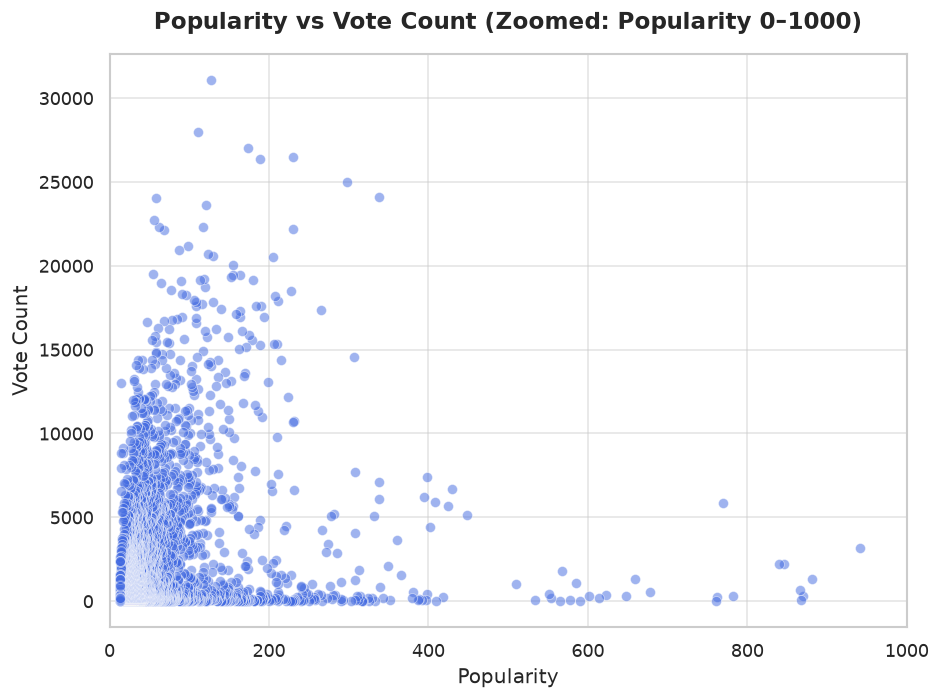

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Popularity', y='Vote_Count', alpha=0.5, color='royalblue')
plt.title('Popularity vs Vote Count (Zoomed: Popularity 0–1000)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Popularity')
plt.ylabel('Vote Count')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

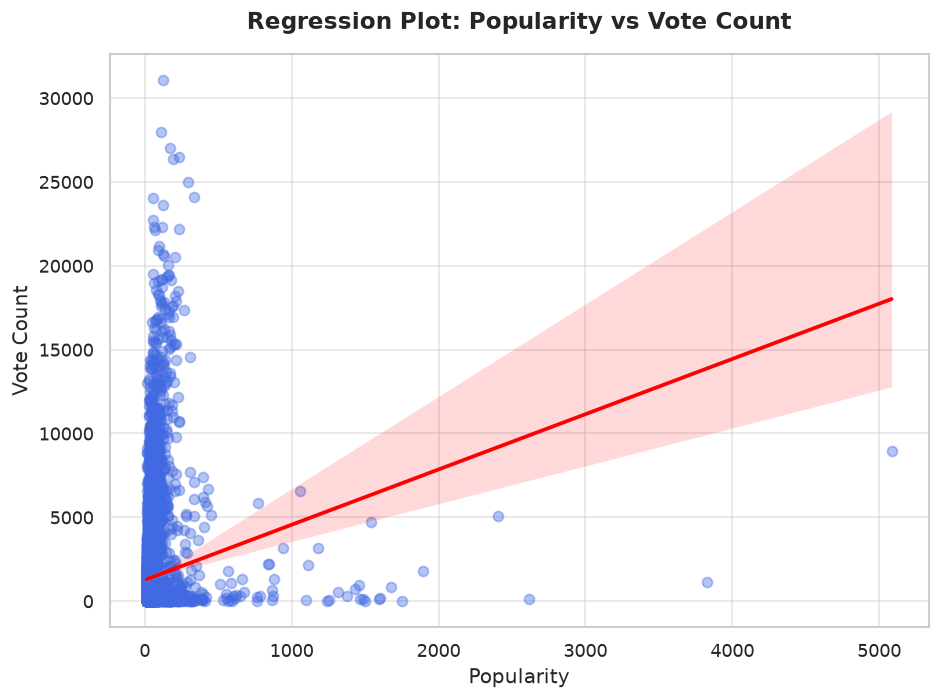

In [32]:
plt.figure(figsize=(8, 6))
sns.regplot(data=df, x='Popularity', y='Vote_Count', scatter_kws={'alpha':0.4, 'color':'royalblue'}, line_kws={'color':'red'})
plt.title('Regression Plot: Popularity vs Vote Count', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Popularity')
plt.ylabel('Vote Count')
plt.tight_layout()
plt.show()

### 4.5 Vote Average (Rating)
Histogram of `Vote_Average` and summary stats. Approximately normal-ish around 6–7, with slight left tail toward lower ratings.

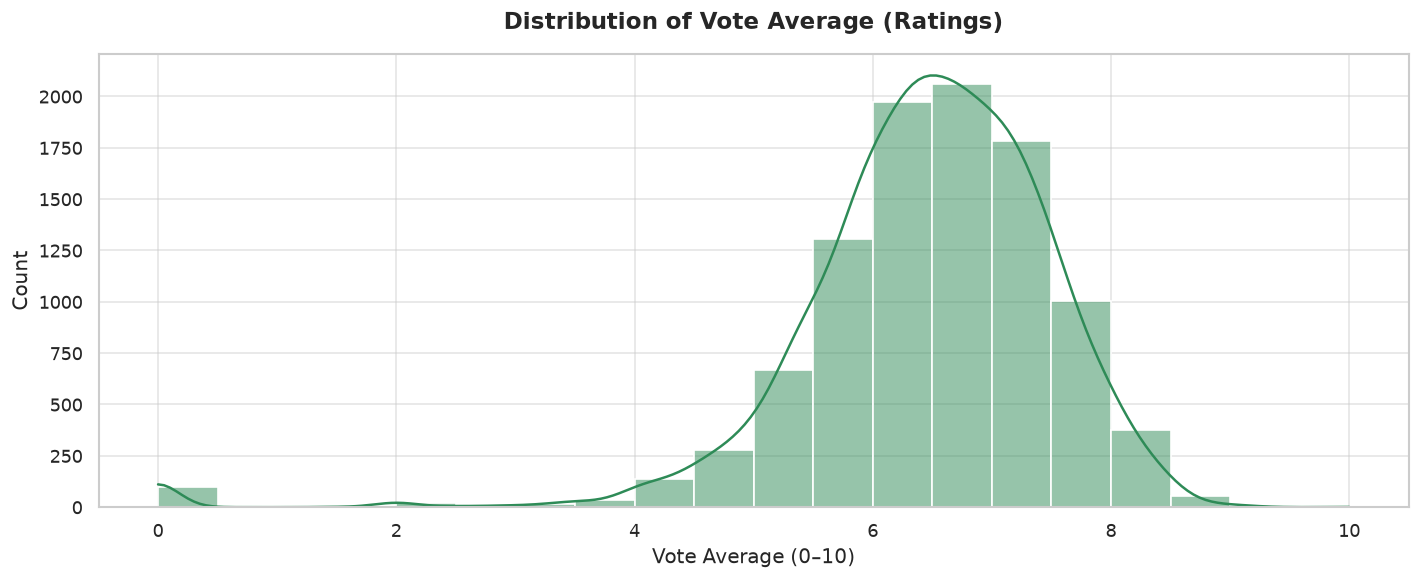

In [33]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='Vote_Average', kde=True, bins=20, color='seagreen')
plt.title('Distribution of Vote Average (Ratings)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Vote Average (0–10)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [34]:
df['Vote_Average'].describe()

count    9826.000000
mean        6.439467
std         1.129797
min         0.000000
25%         5.900000
50%         6.500000
75%         7.100000
max        10.000000
Name: Vote_Average, dtype: float64

## 5. Categorical Analysis
### 5.1 Original Language
English dominates (~7.6k / 9.8k). Japanese, Spanish, French are the next most frequent.

In [35]:
df['Original_Language'].value_counts()

Original_Language
en    7569
ja     645
es     339
fr     292
ko     170
zh     129
it     123
cn     109
ru      83
de      82
pt      37
da      28
hi      26
no      26
sv      23
nl      21
th      17
pl      17
tr      15
id      15
tl       8
te       6
fi       5
sr       5
el       5
cs       4
fa       3
hu       3
is       2
ro       2
uk       2
ar       2
ta       2
he       2
ml       1
nb       1
eu       1
lv       1
ms       1
bn       1
ca       1
la       1
et       1
Name: count, dtype: int64

#### Bar Chart: Movies by Language
Visual confirms the long-tail language distribution. Labels show exact counts.

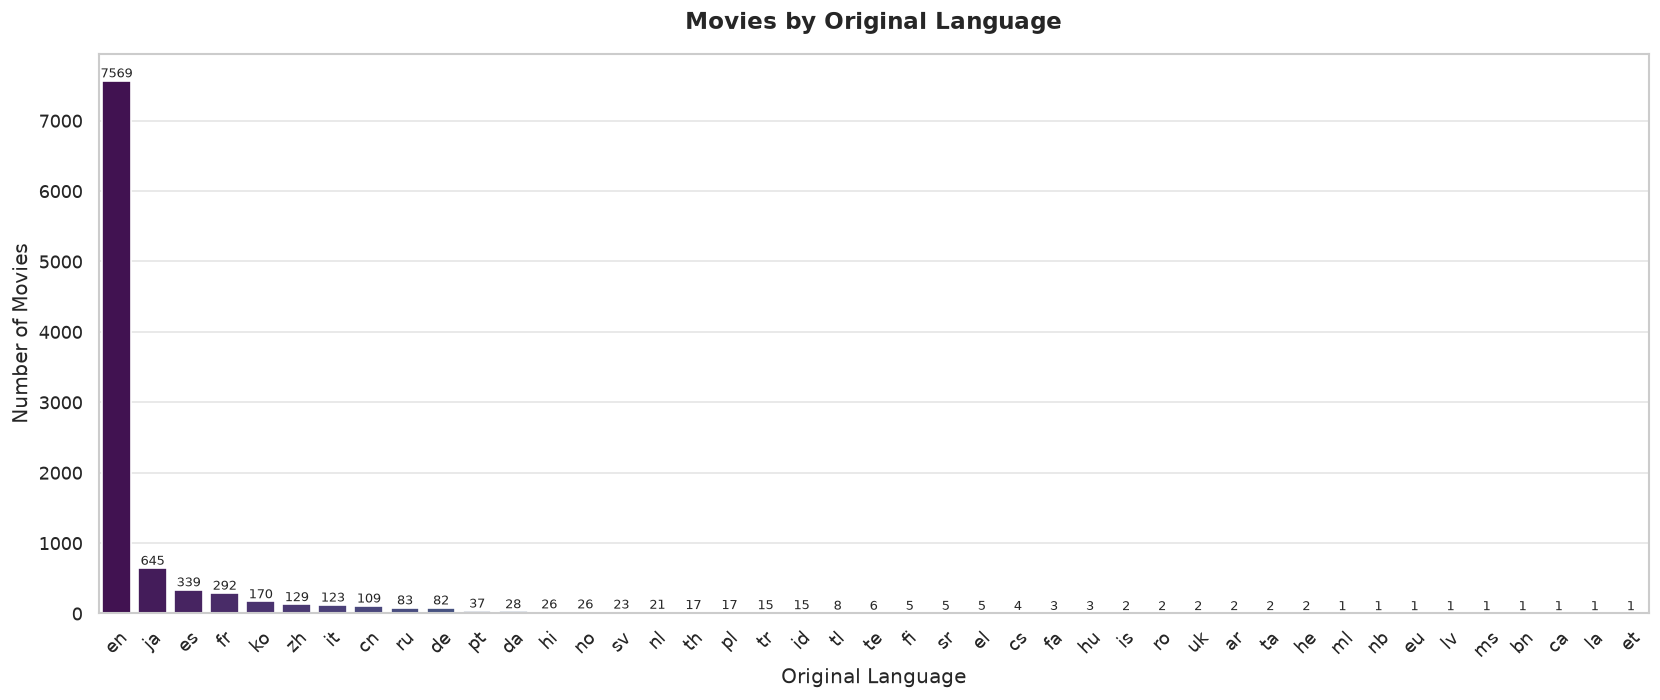

In [36]:
plt.figure(figsize=(14, 6))
lang_counts = df['Original_Language'].value_counts()
ax = sns.barplot(x=lang_counts.index, y=lang_counts.values, hue=lang_counts.index, palette='viridis', legend=False)
plt.title('Movies by Original Language', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Original Language')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
for c in ax.containers:
    ax.bar_label(c, fontsize=8)
plt.tight_layout()
plt.show()

### 5.2 Genre (Multi-label)
Genres are stored as comma-separated lists. Exploding reveals Drama, Comedy, Action as top 3.

In [37]:
df["Genre"].explode().value_counts()

Genre
Drama              3744
Comedy             3031
Action             2686
Thriller           2488
Adventure          1853
Romance            1476
Horror             1470
Animation          1438
Family             1414
Fantasy            1308
Science Fiction    1273
Crime              1242
Mystery             773
History             427
War                 308
Music               295
Documentary         215
TV Movie            214
Western             137
Name: count, dtype: int64

#### Bar Chart: Genre Frequency
Shows genre prevalence across the dataset (a movie can contribute to multiple bars).

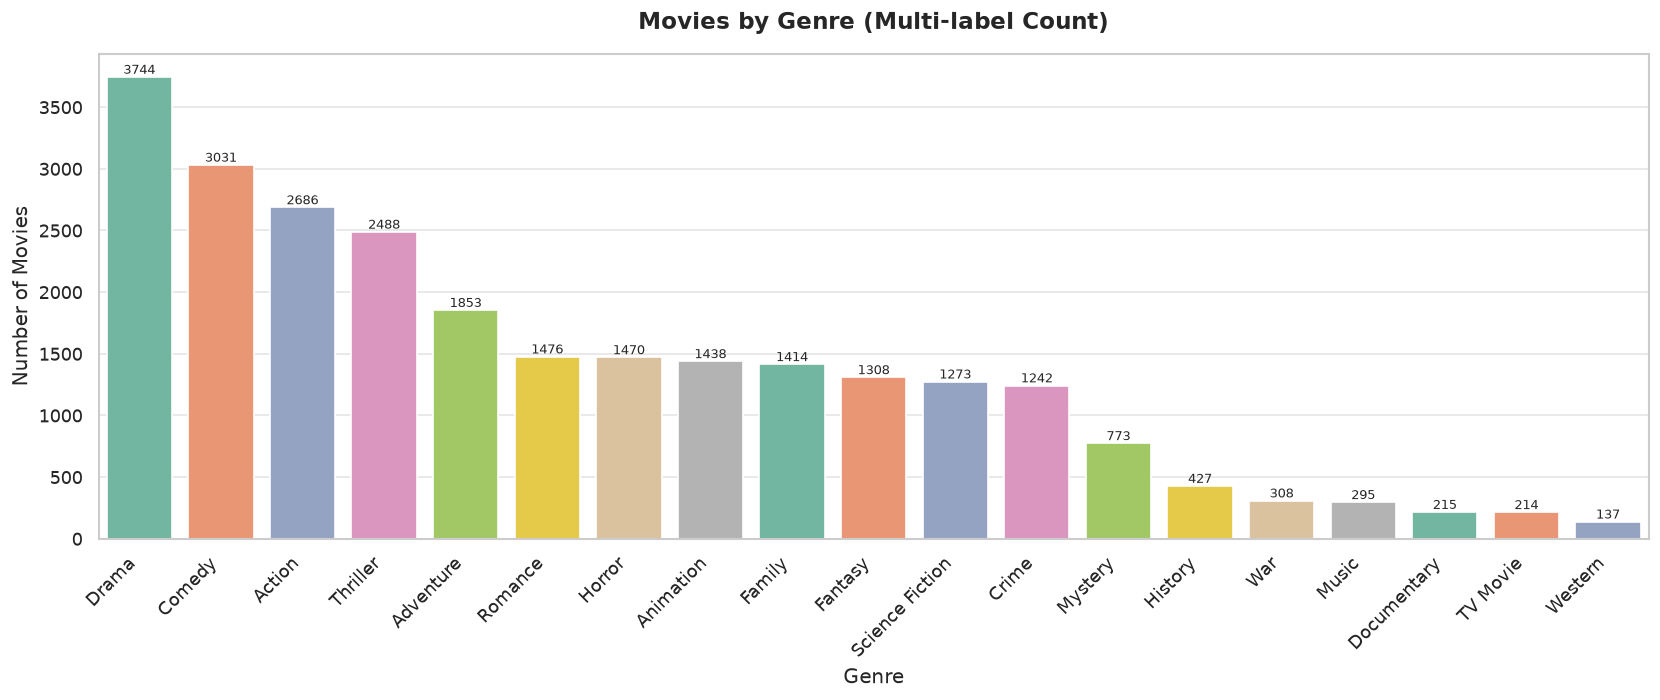

In [38]:
plt.figure(figsize=(14, 6))
genre_counts = df['Genre'].explode().value_counts()
ax = sns.barplot(x=genre_counts.index, y=genre_counts.values, hue=genre_counts.index, palette='Set2', legend=False)
plt.title('Movies by Genre (Multi-label Count)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Genre')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
for c in ax.containers:
    ax.bar_label(c, fontsize=8)
plt.tight_layout()
plt.show()

#### Genre vs Popularity
Explode the genre list, then compute mean popularity per genre to see which genres attract higher average buzz.

In [39]:
genre_df = df.explode("Genre")

#### Bar Chart: Average Popularity by Genre
Higher bars (e.g. Science Fiction, Action) suggest those genres tend to have more popular titles on average — useful for content strategy.

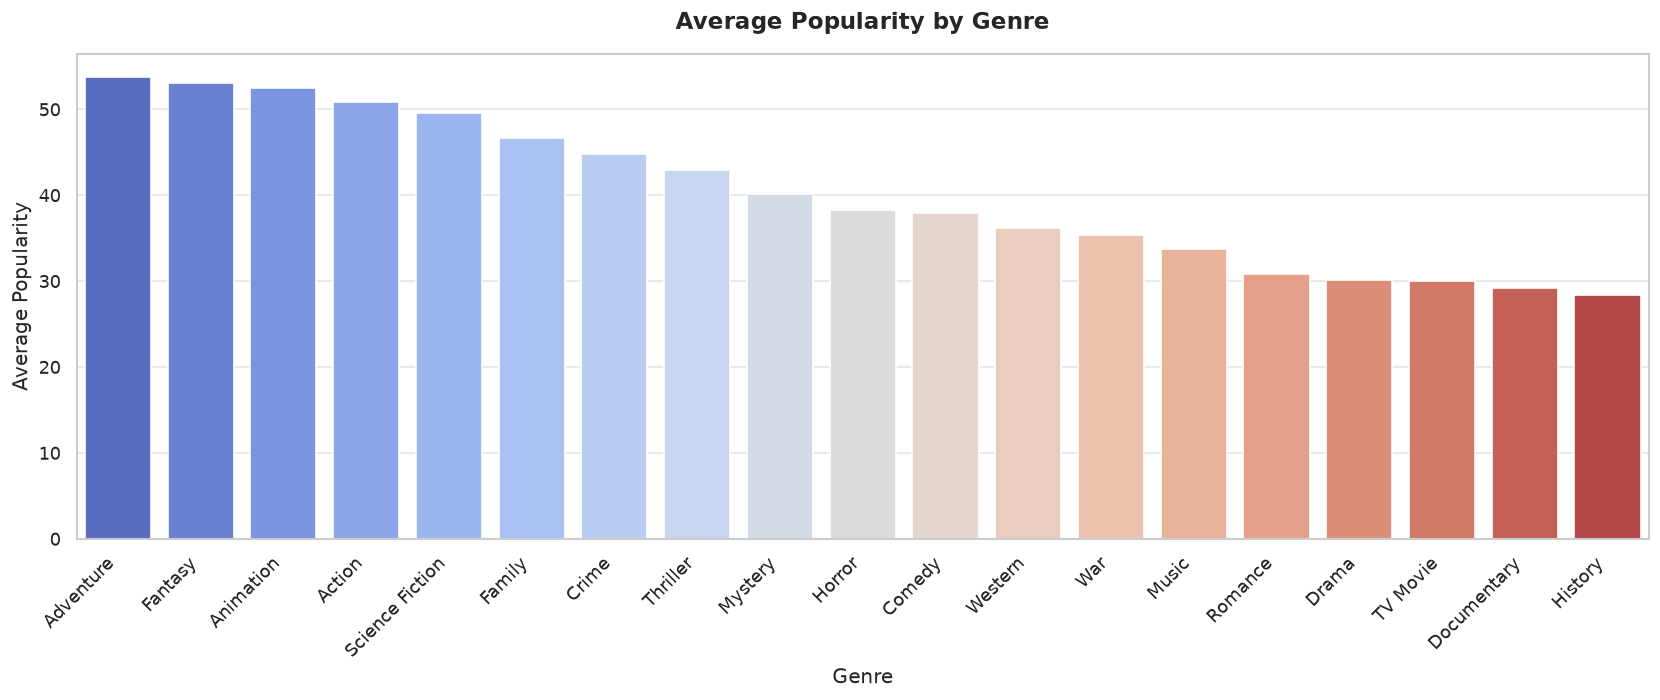

In [40]:
genre_popularity_mean = (
    genre_df.groupby('Genre')['Popularity']
    .mean()
    .sort_values(ascending=False)
)
plt.figure(figsize=(14, 6))
ax = sns.barplot(x=genre_popularity_mean.index, y=genre_popularity_mean.values, hue=genre_popularity_mean.index, palette='coolwarm', legend=False)
plt.title('Average Popularity by Genre', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Genre')
plt.ylabel('Average Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()